# r.traveltime with grass.jupyter

This notebook represents a minimum application of r.traveltime, using the North Carolina dataset. This sample dataset, which is also used in the online documentation of r.traveltime, is downloaded for further analyses in GRASS GIS. If it is already installed, this step is ommitted. Similarly, the `r.traveltime` addon is installed via `g.extension`.

In [1]:
# relevant imports
import grass.jupyter as gj
from grass.tools import Tools
import grass.script as gs
import grass.script.array as garray
from pathlib import Path
import urllib.request
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# download North Carolina data
data_dir = Path.home() / 'data'
data_dir.mkdir(exist_ok=True)

nc_dir = data_dir / 'nc_basic_spm_grass7'
nc_zip = data_dir / 'nc_basic_spm_grass7.zip'

url = 'https://grass.osgeo.org/sampledata/north_carolina/nc_basic_spm_grass7.zip'

if nc_dir.exists():
    print(f'Dataset already exists: {nc_dir}')
else:
    print('Downloading North Carolina basic dataset...')
    urllib.request.urlretrieve(url, nc_zip)

    print('Extracting...')
    with zipfile.ZipFile(nc_zip) as z:
        z.extractall(data_dir)

    nc_zip.unlink()
    print(f'Dataset ready: {nc_dir}')

Dataset already exists: /home/ubuntu/data/nc_basic_spm_grass7


In [3]:
# Initialize GRASS GIS for North Carolina dataset
gisdb = str(Path.home() / 'data')
location = 'nc_basic_spm_grass7'
mapset = 'user1'
tools = Tools()

session = gj.init('~/data/nc_basic_spm_grass7/user1')

In [4]:
# Check if r.traveltime is installed. If not download and compile it via g.extension
if shutil.which('r.traveltime'):
    print('r.traveltime is already installed.')
else:
    print('Installing r.traveltime...')
    tools.g_extension(extension='r.traveltime')
    print('r.traveltime installed.')

r.traveltime is already installed.


If everything works prior to this line, we can now start with the hydrological analyses. The following is a shell script to `grass.jupyter` translation of the exmaple section of the addon's documentation:

In [5]:
# Set computational region to relevant subset
tools.g_region(w=634000, e=635700, s=216920, n=219500)

# generate uniform roughness grid
tools.r_mapcalc(expression='n = 0.1f')

# 1st run of fill
tools.r_fill_dir(input='elevation', output='fill', direction='flowdir', format='agnps', overwrite=True)

# 2nd run
tools.r_fill_dir(input='fill', output='fill2', direction='flowdir2', format='agnps', overwrite=True)

# call r.watershed
tools.r_watershed(elevation='fill2', accumulation='accu', drainage='direction', 
                  threshold=250, flags='as', overwrite=True)

# finally call r.traveltime
tools.r_traveltime(dir='flowdir2', accu='accu', dtm='fill2', manningsn='n',
                  out_x=634613, out_y=217014, threshold=250, b=3, nchannel=0.03,
                  slopemin=0.01, dis=900, out='ttime', overwrite=True)

# final tune for statistics (drop zeros and seconds to hours)
tools.r_mapcalc(expression='ttime = if(ttime <= 0, null(), ttime/3600)', overwrite=True)

# change colors
tools.r_colors(map='ttime', color='water')

Let's plot the results:

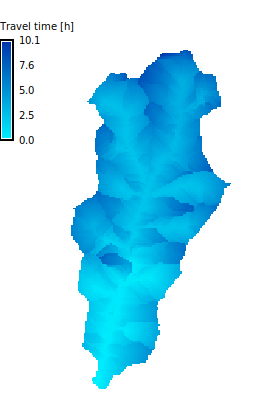

In [6]:
# Start a Map
ttime_map = gj.Map()

# Add a raster, vector and legend to the maplayers
ttime_map.d_rast(map='ttime')
ttime_map.d_legend(raster='ttime', fontsize=10, flags='b', border_color='none', 
                   title=r'Travel time [h]', at=(65, 90, 0, 5))

# Display map
ttime_map.show()

We can now create a histogram of the travel time map. It shows how many cells contribute to water arriving at a given time. This is useful for further hydrological analyses (e.g., unit hydrograph approach).

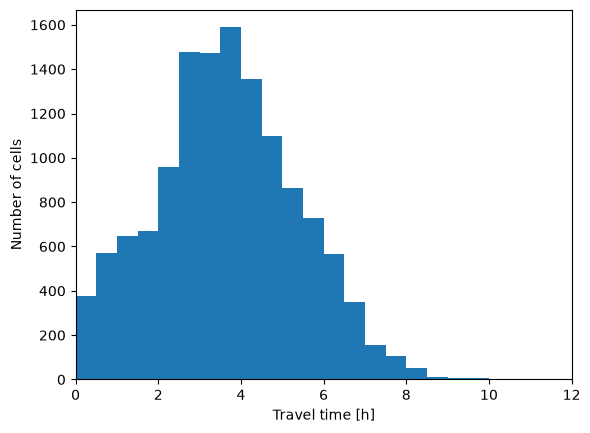

In [7]:
# histogram
values = garray.array("ttime", null=np.nan)
# 0.5-h bins
bins = np.arange(0, 12.5, 0.5)

plt.hist(values.flatten(), bins=bins)
plt.xlabel("Travel time [h]")
plt.ylabel("Number of cells")
plt.xlim(0, 12)
plt.show()